# FRETBursts - ns-ALEX example

*This notebook is part of a [tutorial series](https://github.com/OpenSMFS/FRETBursts_notebooks) for the [FRETBursts](https://opensmfs.github.io/FRETBursts/) burst analysis software.*

> For a step-by-step introduction to FRETBursts usage please refer to 
> [us-ALEX smFRET burst analysis](us-ALEX_translation.ipynb).
>
> In this notebook we present a typical [FRETBursts](https://opensmfs.github.io/FRETBursts/)
> workflow for **ns-ALEX smFRET burst analysis**. 

*While smfBursts does not specifically includes functions for fitting 
TCSPC fluorescence decays, a fitting with exponential decays and 
IRF deconvolution can be easily performed using standard python libraries. 
For an example and a brief discussion see the notebook 
[Lifetime decay fit](https://nbviewer.ipython.org/github/tritemio/notebooks/blob/master/Lifetime_decay_fit.ipynb).*

## Loading FRETBursts

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# from fretbursts import *
import smfbursts as smf

## Downloading the sample data file

The full list of smFRET measurements used in the [FRETBursts tutorials](https://github.com/OpenSMFS/FRETBursts_notebooks) 
can be found on [Figshare](http://dx.doi.org/10.6084/m9.figshare.1456362).

> ** Old Text**
> Here we download the ns-ALEX data-file and put it in a folder 
> named `data`, inside the notebook folder. 
> For this purpose we use the `download_file` function provided 
> by FRETBursts:

Now downloading is recomended to be done using the `pooch` package (not part of smfBursts)

In [2]:
filename = 'data/HP3_TE300_SPC630.hdf5'
filename

'data/HP3_TE300_SPC630.hdf5'

In [3]:
import os
if os.path.isfile(filename):
    print("Perfect, I found the file!")
else:
    print("Sorry, I can't find the file:\n%s" % filename)

Perfect, I found the file!


## Load the selected file

Here we load the file and we set the alternation parameters:

In [4]:
# d = loader.photon_hdf5(filename)
raw = smf.photonHDF5.load(filename)

In [5]:
# d.time_max
raw.times[0][-1]

np.int64(100187059037)

In [6]:
# d.det_t
raw.dets[0]

array([0, 1, 1, ..., 1, 1, 1], shape=(11836058,), dtype=uint8)

In [7]:
# print("Detector    Counts")
# print("--------   --------")
# for det, count in zip(*np.unique(d.det_t, return_counts=True)):
#     print("%8d   %8d" % (det, count))
print("Detector    Counts")
print("--------   --------")
for det, count in zip(*np.unique(raw.dets[0], return_counts=True)):
    print("%8d   %8d" % (det, count))

Detector    Counts
--------   --------
       0    6378957
       1    5457101


In [8]:
# d.add(A_ON=(130, 1850), D_ON=(2250, 3750), det_donor_accept=(4, 6))

# modify alternation period in raw as follows:
# raw.photon_data[0].meas_specs['alex_excitaion_period1'] = np.array([2250, 3750])
# raw.photon_data[0].meas_specs['alex_excitaion_period2'] = np.array([130, 1850])

# detectors can be assigned as follows
# raw.photon_data[0].meas_specs['detectors_specs']['spectral_ch1'] = np.array([1], dtype=np.uint8)
# raw.photon_data[0].meas_specs['detectors_specs']['spectral_ch2'] = np.array([0], dtype=np.uint8)

In [9]:
# d.nanotimes_t
raw.nanos[0]

array([2477, 2347, 2570, ..., 2334, 2795,  178],
      shape=(11836058,), dtype=uint16)

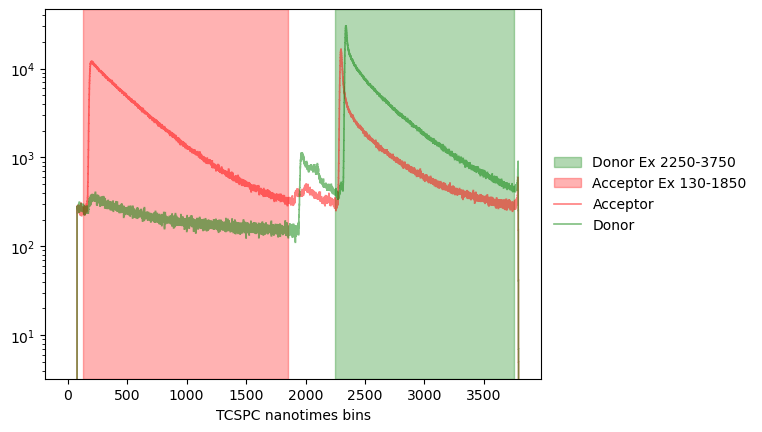

In [10]:
# bpl.plot_alternation_hist(d)
smf.plot.alternation_hist(raw)

Execute the previous 2 cells until you get a satisfying 
selection for the excitation periods. Then run the following 
to apply the parameters:

In [11]:
# loader.alex_apply_period(d)
data = smf.photonHDF5.regularize_dets(raw)

## Burst search and selection

In [12]:
# d.calc_bg(fun=bg.exp_fit, time_s=30, tail_min_us='auto', F_bg=1.7)
bg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, period=30.0, auto_threshold=True, F_bg=1.7)

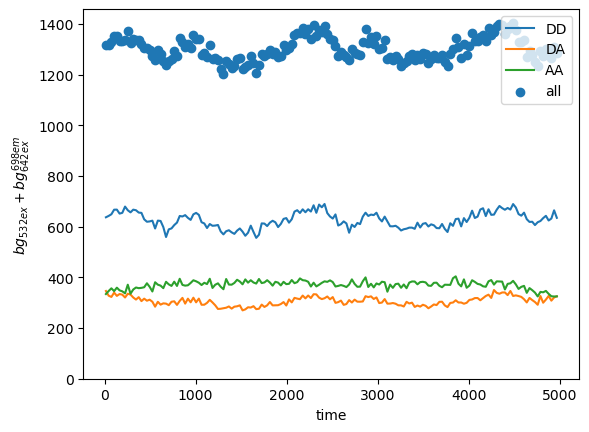

In [13]:
#dplot(d, timetrace_bg)
smf.plot.time_plot(data, bg['BgDD'], label='DD')
smf.plot.time_plot(data, bg['BgDA'], label='DA')
smf.plot.time_plot(data, bg['BgAA'], label='AA')
smf.plot.time_scatter(data, bg['BgAll'], label='all')
plt.ylim(0)
plt.legend()

In smfBursts the `bg` and `bg_kwargs` keyword arguments can be added to plot lines of the background rate in the current period.

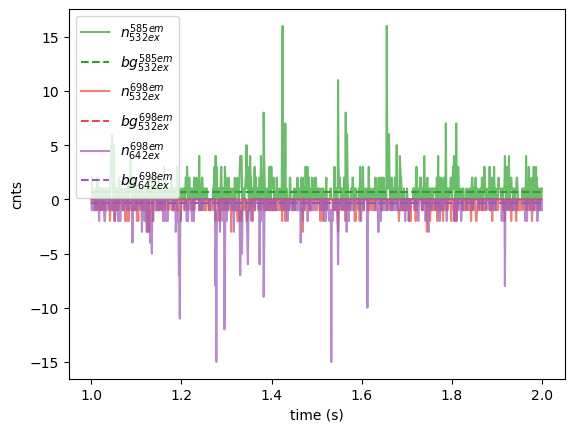

In [14]:
# dplot(d, timetrace)
# xlim(1, 2)
# ylim(-50, 50)
smf.plot.timetrace(data, streams=smf.fretfactory.ALEXdefaults.streams[1:], 
                   stream_kwargs=smf.fretfactory.ALEXdefaults.stream_colors[1:],
                   bg=bg['bg'], bg_kwargs={'ls':'--'},
                   direction=(1,-1, -1), alpha=0.7, tmin=1.0, tmax=2.0);

Perform/create the burst search parameters

In [15]:
# d.burst_search()
bursts = smf.fretfactory.make_burst_search(bg['bg'], m=10, F=6.0, streams=smf.PhSel('0ex_1ex1em'))

Select bursts according to `DexDem + DexAem >= 30`

In [16]:
# ds = d.select_bursts(select_bursts.size, th1=30)
gS = smf.make_geq_gate(bursts['NphDex_bg'], 30.0)

Plot E-S histogram

> **Note**
>
> The command is simpoler in smfBursts when using a simple `scatter` plot instead of `hexbin`

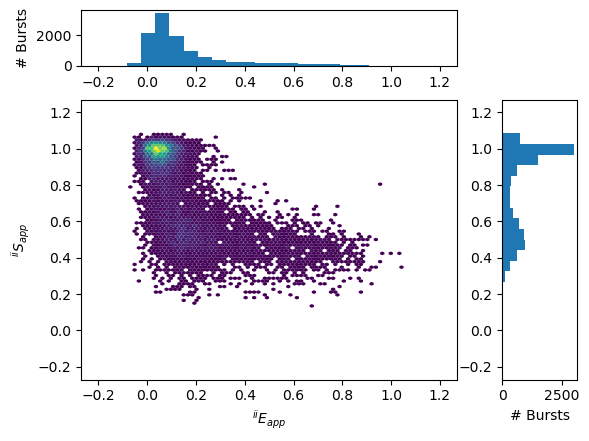

In [17]:
# alex_jointplot(ds)
smf.plot.jointplot(data, bursts['E_bg'], bursts['S_bg'], gate=gS, cfunc=smf.plot.hexbin,
                   cplot_kwargs={'gridsize':80, 'extent':(-0.2,1.2,-0.2,1.2), 
                                 'mincnt':1, 'edgecolor':'none', 'linewidth':0.2},
                   hplot_kwargs={'bins':np.linspace(-0.2,1.2, 25)});

Apply leakage correction.

> **See Also**
>
> In this notebook the leakage factor is assumed.
> There are methods to calculate, such as from [Hellenkamp et. al.](https://doi.org/10.1038/nmeth.4081)
> See the [BurstTutorial](BurstsTutorial.ipynb#Correction-Factors) for an example of this calculation using smfBursts.

In [18]:
# ds.leakage = 0.05
lkcorr = smf.fretfactory.make_correction_factors(alpha=0.05, update=bursts)

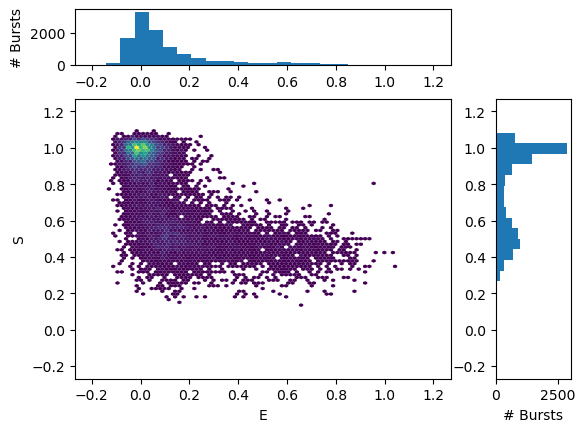

In [19]:
# alex_jointplot(ds)
smf.plot.jointplot(data, bursts['E'], bursts['S'], gate=gS, cfunc=smf.plot.hexbin,
                   cplot_kwargs={'gridsize':80, 'extent':(-0.2,1.2,-0.2,1.2), 
                                 'mincnt':1, 'edgecolor':'none', 'linewidth':0.2},
                   hplot_kwargs={'bins':np.linspace(-0.2,1.2, 25)});

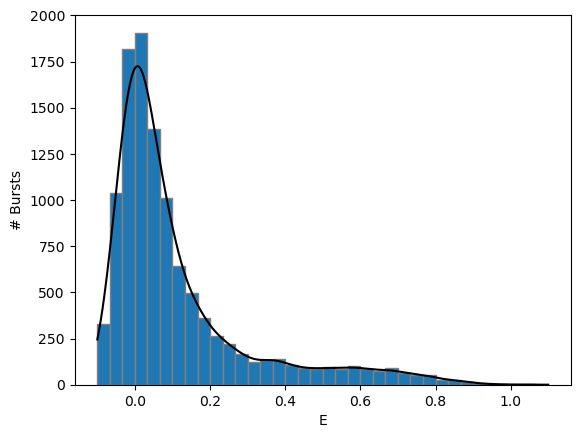

In [20]:
# dplot(ds, hist_fret, show_kde=True)

smf.plot.hist_kdeoverlay(data, bursts['E'], gate=gS, bins=np.linspace(-0.1, 1.1, 37), kdeplot_kwargs={'c':'k'}, edgecolor='grey');

## Nanotimes

The nanotimes for the measurement is saved in the `.nanotimes` 
attribute of the `Data()` object (here either `d` or `ds`).

As an example here we get the array of nanotimes for all photons, 
donor emission and acceptor emission:

In [21]:
# d.nanotimes
data.nanos

array([2477, 2347, 2570, ..., 2334, 2795,  178],
      shape=(11415388,), dtype=uint16)

In [22]:
# nanotimes = d.nanotimes[0]
# nanotimes_d = nanotimes[d.get_D_em()]
# nanotimes_a = nanotimes[d.get_A_em()]
nanotimes = data.get_nanos(smf.PhSel('all'))
nanotimes_d = data.get_nanos(smf.PhSel('0ex'))
nanotimes_a = data.get_nanos(smf.PhSel('1ex1em'))

We can plot the histogram for this 3 nanotimes:

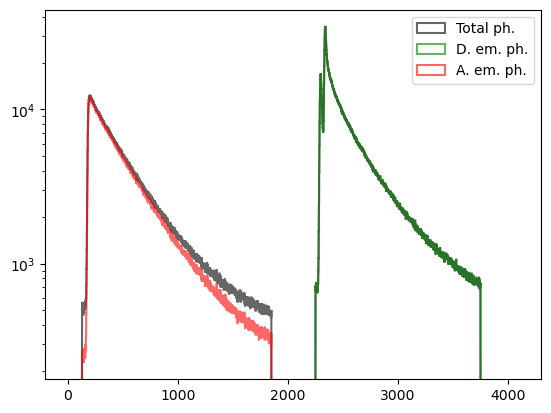

In [23]:
# hist_params = dict(bins=range(4096), histtype='step', alpha=0.6, lw=1.5)
# hist(nanotimes, color='k', label='Total ph.', **hist_params)
# hist(nanotimes_d, color='g', label='D. em. ph.', **hist_params)
# hist(nanotimes_a, color='r', label='A. em. ph.', **hist_params)
# plt.legend()
# plt.yscale('log')

hist_params = dict(bins=range(4096), histtype='step', alpha=0.6, lw=1.5)
plt.hist(nanotimes, color='k', label='Total ph.', **hist_params)
plt.hist(nanotimes_d, color='g', label='D. em. ph.', **hist_params)
plt.hist(nanotimes_a, color='r', label='A. em. ph.', **hist_params)
plt.legend()
plt.yscale('log')

We can also select only nanotimes of photons inside bursts. 
Here, as an example, we will use the `ds` variable that 
contains a selection of bursts.

First we compute a selection mask (a boolean array) for 
photons inside bursts:

In [24]:
# ph_in_bursts_mask = d.ph_in_bursts_mask_ich()

Then we apply this selection to the nanotimes array. 
To get the donor- and acceptor-emission nanotimes we combine 
the in-bursts selection mask (`ph_in_bursts_mask`) with 
the donor or acceptor emission mask (that we get with
`.get_D_em()` and `.get_D_em()`):

In [25]:
# bursts_nanotimes_t = nanotimes[ph_in_bursts_mask]
# bursts_nanotimes_d = nanotimes[ph_in_bursts_mask * d.get_D_em()]
# bursts_nanotimes_a = nanotimes[ph_in_bursts_mask * d.get_A_em()]
bursts_nanotimes_t = np.concatenate(data.get_column(smf.Column(bursts['bursts'], 'ph_nanos', smf.PhSel('all'))))
bursts_nanotimes_d = np.concatenate(data.get_column(smf.Column(bursts['bursts'], 'ph_nanos', smf.PhSel('0ex'))))
bursts_nanotimes_a = np.concatenate(data.get_column(smf.Column(bursts['bursts'], 'ph_nanos', smf.PhSel('1ex'))))

And, as before, we can histogram the nanotimes:

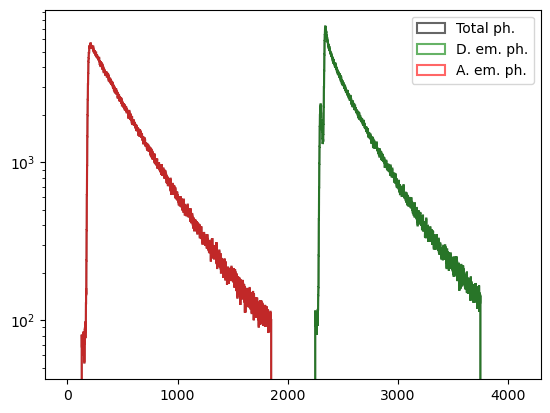

In [26]:
# hist_params = dict(bins=range(4096), histtype='step', alpha=0.6, lw=1.5)
# hist(bursts_nanotimes_t, color='k', label='Total ph.', **hist_params)
# hist(bursts_nanotimes_d, color='g', label='D. em. ph.', **hist_params)
# hist(bursts_nanotimes_a, color='r', label='A. em. ph.', **hist_params)
# plt.legend()
# plt.yscale('log')
hist_params = dict(bins=range(4096), histtype='step', alpha=0.6, lw=1.5)
plt.hist(bursts_nanotimes_t, color='k', label='Total ph.', **hist_params)
plt.hist(bursts_nanotimes_d, color='g', label='D. em. ph.', **hist_params)
plt.hist(bursts_nanotimes_a, color='r', label='A. em. ph.', **hist_params)
plt.legend()
plt.yscale('log')

Note: the columnn nanohist allows 

## Saving to a file

Saving some of all these arrays to file is straightforward.

### Save array to txt comma-separed-values

To save a single array to a file we can use the [`.tofile`](http://docs.scipy.org/doc/numpy/reference/generated/numpy.ndarray.tofile.html) method:

> **Note**
>
> This does not direclty invoke FRETBursts, a more complete save method is shown below.

In [27]:
# this is a very simple way, 
nanotimes.tofile('nanotimes_t.csv', sep=',\n')  # save in CSV txt format

New: save columns to csv

In [28]:
data.to_csv(bursts['E'], bursts['S'], bursts['NphDD_c'], bursts['NphDA_c'], bursts['NphAA_c'], gate=gS, path_or_buf='burst_data.csv')

### Save to legacy MATLAB format

To save a set of arrays in MATLAB format  we can use the 
[`scipy.io.savemat`](http://docs.scipy.org/doc/scipy-0.13.0/reference/generated/scipy.io.savemat.html) function.

Here we save 3 arrays `bursts_nanotimes_t`, `bursts_nanotimes_d` 
and `bursts_nanotimes_a` to a file called *bursts_nanotimes.mat*:

In [29]:
from scipy.io import savemat

In [30]:
savemat('bursts_nanotimes.mat', 
        dict(bn_t=bursts_nanotimes_t, 
             bn_d=bursts_nanotimes_d, 
             bn_a=bursts_nanotimes_a,))

When loaded in MATLAB the arrays will be named `bn_t`, `bn_d` and `bn_a`.

**Reminder: print your citations (new to smfBursts)**

In [31]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
3. Hellenkamp, B., Schmid, S., Doroshenko, O. et al. Precision and accuracy of
    single-molecule FRET measurements—a multi-laboratory benchmark study. Nat
    Methods 15, 669–676 (2018).
